# Annual and July–August FPC difference maps

### July–August mean FPC files

The `july_august_mean_as_max_fpc.py` script:
- Calculates the mean of July and August for every grid cell and LPJ-GUESS PFT:
   $$
   FPC_{\mathrm{Jul-Aug}}=\frac{FPC_{\mathrm{July}}+FPC_{\mathrm{August}}}{2}.
   $$
- Calculates the grid-cell total using the natural and peatland land-cover fractions:
   $$
   Total = Natural\_sum \times NATURAL + Peatland\_sum \times PEATLAND.
   $$
- Writes historical and future `_max` files with the same columns and coordinate order as the original annual-mean FPC files.

### This notebook compares the original annual-mean FPC files with the files with "max FPC".

$\rightarrow$ Here, `_max` represents a **July–August peak-season proxy**, not the mathematical maximum across all months.

For each CLM group, the main figure shows:

1. $\Delta FPC_{annual}=FPC_{future}-FPC_{historical}$
2. $\Delta FPC_{max}=FPC_{future,max}-FPC_{historical,max}$
3. $\Delta FPC_{max}-\Delta FPC_{annual}$

A second figure shows `_max − annual` separately for the historical and future periods.

## 👉 Conclusion
Oh. So the **peak resembles the original annual files very much**... Further investigation needed. Look at `06b-compare_historical_and_GFDL_ESM4_monthly_vs_annual_FPC`.

## 1. Imports and plotting style

The notebook requires `numpy`, `pandas`, `matplotlib`, and `cartopy` in the active environment.


In [1]:
from pathlib import Path
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm
from matplotlib.path import Path as MplPath

import cartopy.crs as ccrs
import cartopy.feature as cfeature


plt.rcParams.update({
    "font.family": "STIXGeneral",
    "mathtext.fontset": "stix",
    "font.size": 11,
    "axes.titlesize": 12,
})


## 2. Paths and CLM groups

Change only `DATA_DIR` if the files are stored elsewhere. Figures are saved as both PNG and PDF.


In [9]:
DATA_DIR = Path("~/BOREAL-FOREST-EXPANSION/data/edit-surfdata/LPJ-GUESS").expanduser()
FIGURE_DIR = Path("06-original_vs_monthly_comparison_figures/annual_vs_max_difference")

FPC_FILES = {
    "historical annual": DATA_DIR / "fpc1971to2000.txt",
    "future annual": DATA_DIR / "GFDL-ESM4_SSP585_fpc2071to2100.txt",
    "historical max": DATA_DIR / "fpc1971to2000_max.txt",
    "future max": DATA_DIR / "GFDL-ESM4_SSP585_fpc2071to2100_max.txt",
}

GROUPS = {
    "BoNET": ["BNE", "BINE"],
    "BoNDT (larch)": ["BNS"],
    "BoBDT": ["IBS"],
    "BoBDS shrubs": ["HSE", "HSS", "LSE", "LSS", "EPDS", "SPDS"],
    "aC3": ["C3G", "GRT"],
    "temperate trees": ["TeNE", "TeBE", "TeBS"],
}

SCALE_PERCENTILE = 99
MAP_EXTENT = [-180, 180, 45, 90]


## 3. Read and validate the four files

The checks require the same coordinate set in all four files. The `_max` files may have a different row order because all calculations align explicitly by longitude and latitude.


In [3]:
def read_fpc(path):
    """Read one whitespace-delimited FPC file and validate its required content."""
    if not path.exists():
        raise FileNotFoundError(path)

    frame = pd.read_csv(path, sep=r"\s+", dtype=str, low_memory=False)
    if not {"Lon", "Lat"}.issubset(frame.columns):
        raise ValueError(f"{path}: missing Lon or Lat")

    repeated_header = frame["Lon"].eq("Lon") | frame["Lat"].eq("Lat")
    frame = frame.loc[~repeated_header].copy()

    required_pfts = {pft for members in GROUPS.values() for pft in members}
    missing = required_pfts.difference(frame.columns)
    if missing:
        raise ValueError(f"{path}: missing PFT columns {sorted(missing)}")

    for column in frame.columns:
        frame[column] = pd.to_numeric(frame[column], errors="raise")

    if frame.duplicated(["Lon", "Lat"]).any():
        raise ValueError(f"{path}: duplicate Lon/Lat rows")
    if frame[list(required_pfts)].isna().any().any():
        raise ValueError(f"{path}: missing values in required PFT columns")

    return frame


def coordinate_index(frame):
    """Return the unique coordinate pairs in a frame."""
    return pd.MultiIndex.from_frame(frame[["Lon", "Lat"]], names=["Lon", "Lat"])


def validate_same_grid(frames):
    """Stop if any file has missing or additional grid cells."""
    reference_name = next(iter(frames))
    reference = coordinate_index(frames[reference_name])

    for name, frame in frames.items():
        current = coordinate_index(frame)
        missing = reference.difference(current)
        extra = current.difference(reference)
        if len(missing) or len(extra):
            raise ValueError(
                f"Grid mismatch for {name}: {len(missing)} cells missing and "
                f"{len(extra)} additional cells relative to {reference_name}"
            )

    print(f"All four files use the same grid: {len(reference):,} cells.")


def aggregate_to_clm_groups(frame):
    """Sum the LPJ-GUESS PFT columns belonging to each CLM group."""
    grouped = frame[["Lat", "Lon"]].copy()
    for group, members in GROUPS.items():
        grouped[group] = frame[members].sum(axis=1)
    return grouped.set_index(["Lat", "Lon"]).sort_index()


frames = {name: read_fpc(path) for name, path in FPC_FILES.items()}
validate_same_grid(frames)
fpc = {name: aggregate_to_clm_groups(frame) for name, frame in frames.items()}

for name, path in FPC_FILES.items():
    print(f"{name:20s} {len(frames[name]):6,d} cells  {path.name}")


All four files use the same grid: 16,750 cells.
historical annual    16,750 cells  fpc1971to2000.txt
future annual        16,750 cells  GFDL-ESM4_SSP585_fpc2071to2100.txt
historical max       16,750 cells  fpc1971to2000_max.txt
future max           16,750 cells  GFDL-ESM4_SSP585_fpc2071to2100_max.txt


## 4. Calculate the differences

The requested difference-of-differences has two equivalent forms:

$$
(F_{max}-H_{max})-(F_{annual}-H_{annual})
=
(F_{max}-F_{annual})-(H_{max}-H_{annual}).
$$

The equality check below guards against alignment or sign errors.


In [4]:
annual_change = fpc["future annual"] - fpc["historical annual"]
max_change = fpc["future max"] - fpc["historical max"]
difference_of_differences = max_change - annual_change

historical_max_minus_annual = fpc["historical max"] - fpc["historical annual"]
future_max_minus_annual = fpc["future max"] - fpc["future annual"]
equivalent_difference = future_max_minus_annual - historical_max_minus_annual

if not np.allclose(
    difference_of_differences.to_numpy(),
    equivalent_difference.to_numpy(),
    atol=1e-12,
    rtol=0,
):
    raise AssertionError("The two difference-of-differences calculations disagree")

print("Difference-of-differences identity verified.")


Difference-of-differences identity verified.


## 5. Map helpers

Each figure uses one symmetric colour scale across its panels. The limit is based on the 99th percentile of the absolute plotted values, reducing the influence of isolated extremes while retaining them through the extended colour bar.


In [5]:
def save_figure(fig, name):
    """Save a figure as high-resolution PNG and vector PDF."""
    FIGURE_DIR.mkdir(parents=True, exist_ok=True)
    fig.savefig(FIGURE_DIR / f"{name}.png", dpi=300, bbox_inches="tight")
    fig.savefig(FIGURE_DIR / f"{name}.pdf", bbox_inches="tight")


def configure_arctic_axis(ax):
    """Apply the shared Arctic orthographic map style."""
    ax.set_extent(MAP_EXTENT, crs=ccrs.PlateCarree())
    ax.add_feature(cfeature.OCEAN, facecolor="0.97", zorder=0)
    ax.add_feature(cfeature.LAND, facecolor="0.94", zorder=0)
    ax.coastlines(color="0.45", linewidth=0.55)
    ax.add_feature(cfeature.BORDERS, edgecolor="0.65", linewidth=0.35)
    ax.gridlines(color="0.82", linewidth=0.4, linestyle=":")

    theta = np.linspace(0, 2 * np.pi, 200)
    circle = np.column_stack([np.sin(theta), np.cos(theta)]) * 0.5 + 0.5
    ax.set_boundary(MplPath(circle), transform=ax.transAxes)


def symmetric_norm(fields):
    """Build one zero-centred colour scale for a list of map fields."""
    values = np.concatenate([field.to_numpy().ravel() for field in fields])
    values = values[np.isfinite(values)]
    vmax = max(float(np.percentile(np.abs(values), SCALE_PERCENTILE)), 1e-6)
    return TwoSlopeNorm(vmin=-vmax, vcenter=0, vmax=vmax)


def draw_field(ax, field, title, norm):
    """Draw a coordinate-indexed pandas Series as an Arctic map."""
    grid = field.rename("FPC").reset_index().pivot(index="Lat", columns="Lon", values="FPC")
    configure_arctic_axis(ax)
    image = ax.pcolormesh(
        grid.columns, grid.index, grid.to_numpy(),
        transform=ccrs.PlateCarree(), shading="auto",
        cmap="BrBG", norm=norm, rasterized=True,
    )
    ax.set_title(title)
    return image


def safe_name(text):
    """Convert a group label to a compact filename component."""
    return re.sub(r"[^a-z0-9]+", "_", text.lower()).strip("_")


## 6. Future-minus-historical comparison

These are the main requested maps. The third panel shows how using the July–August proxy changes the inferred future-minus-historical FPC anomaly relative to using annual means.


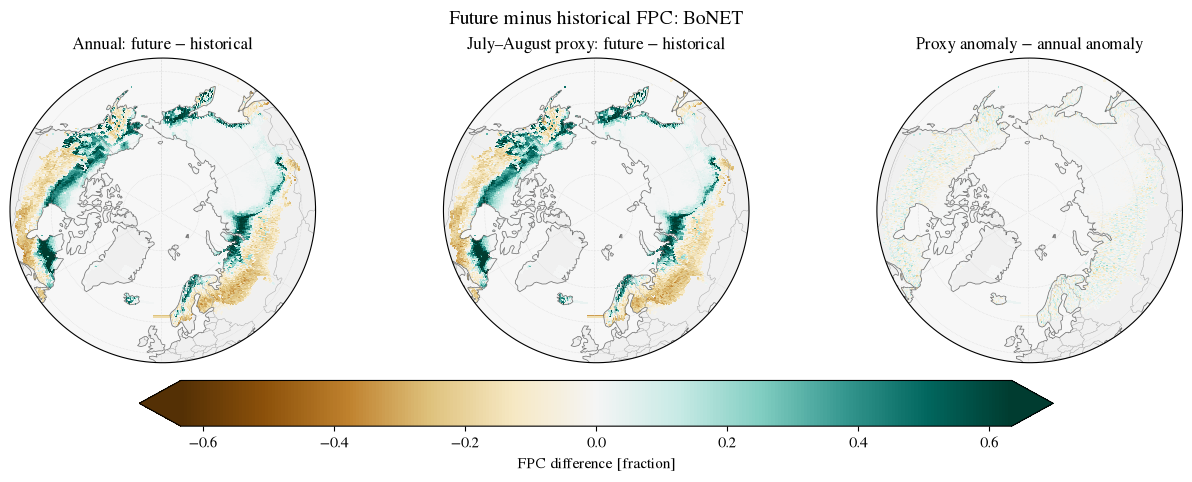

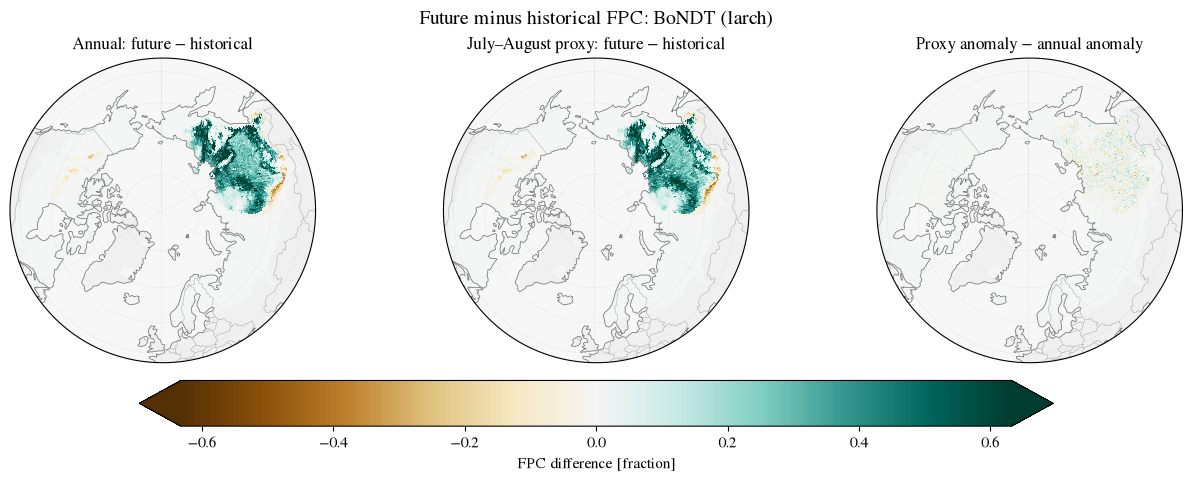

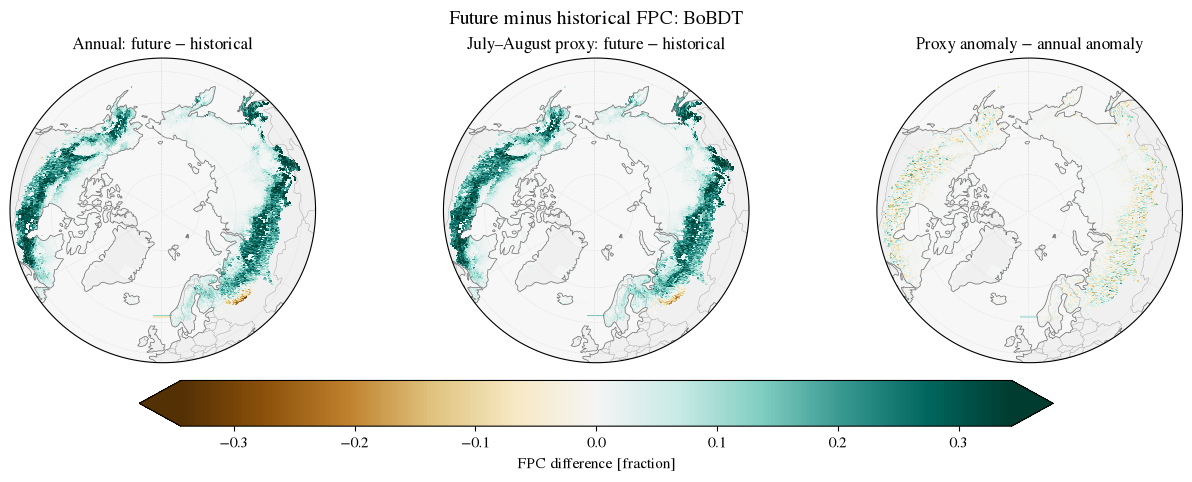

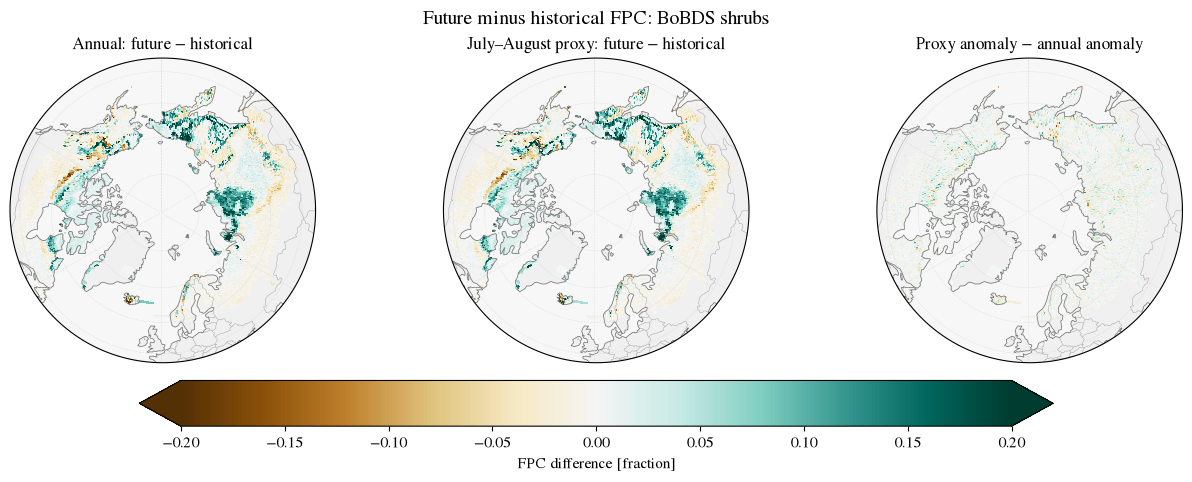

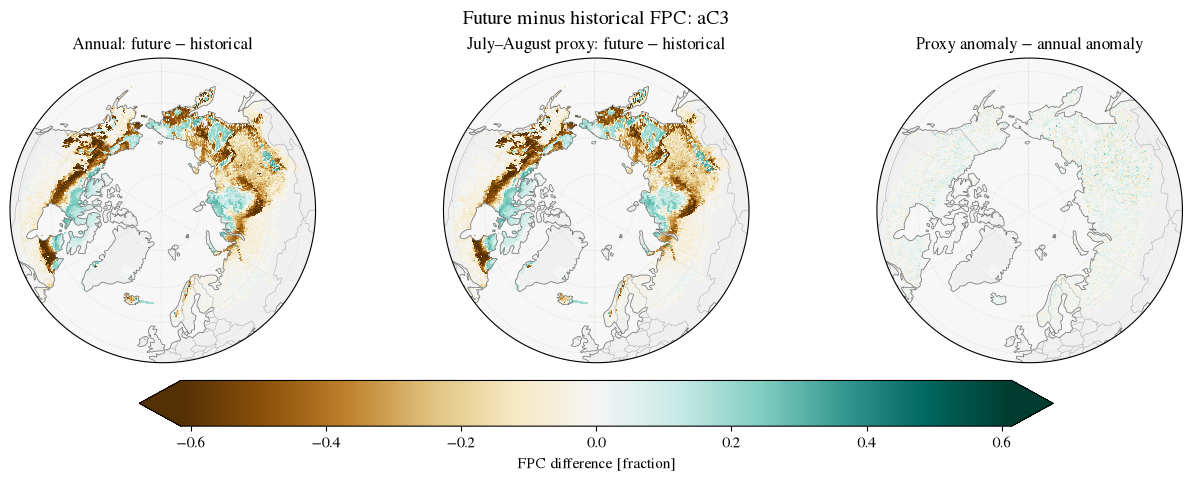

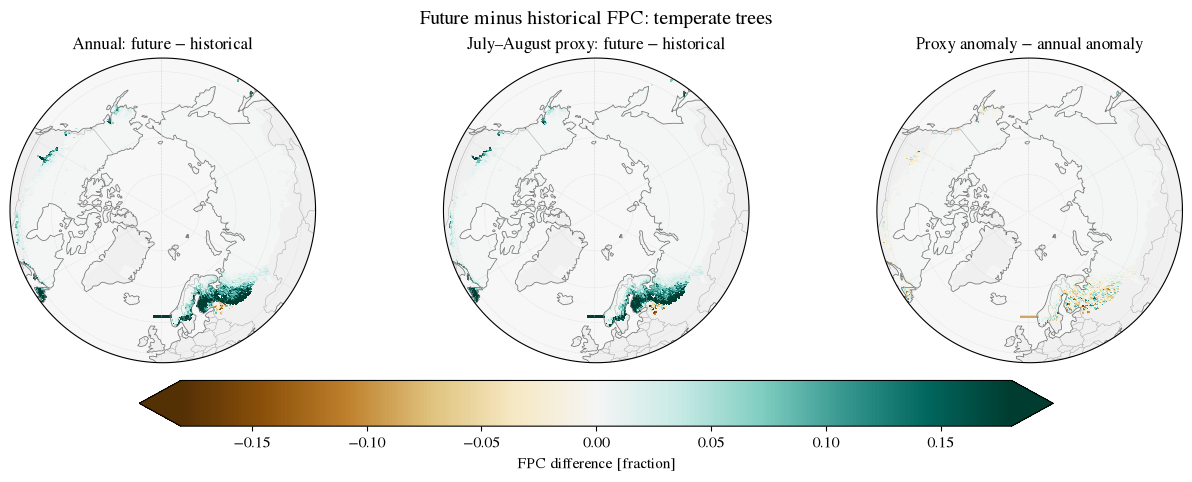

In [6]:
def plot_change_comparison(group):
    fields = [
        annual_change[group],
        max_change[group],
        difference_of_differences[group],
    ]
    titles = [
        r"Annual: future $-$ historical",
        r"July–August proxy: future $-$ historical",
        r"Proxy anomaly $-$ annual anomaly",
    ]

    projection = ccrs.Orthographic(central_longitude=0, central_latitude=90)
    fig, axes = plt.subplots(
        1, 3, figsize=(13, 4.7), subplot_kw={"projection": projection},
        layout="constrained",
    )
    norm = symmetric_norm(fields)

    for ax, field, title in zip(axes, fields, titles):
        image = draw_field(ax, field, title, norm)

    colorbar = fig.colorbar(
        image, ax=axes, orientation="horizontal", shrink=0.72,
        pad=0.05, extend="both",
    )
    colorbar.set_label("FPC difference [fraction]")
    fig.suptitle(f"Future minus historical FPC: {group}", fontsize=14)
    save_figure(fig, f"future_minus_historical_annual_vs_max_{safe_name(group)}")
    plt.show()


for group in GROUPS:
    plot_change_comparison(group)


## 7. July–August proxy minus annual mean

These maps isolate the effect of replacing annual-mean FPC with the July–August proxy within each period.


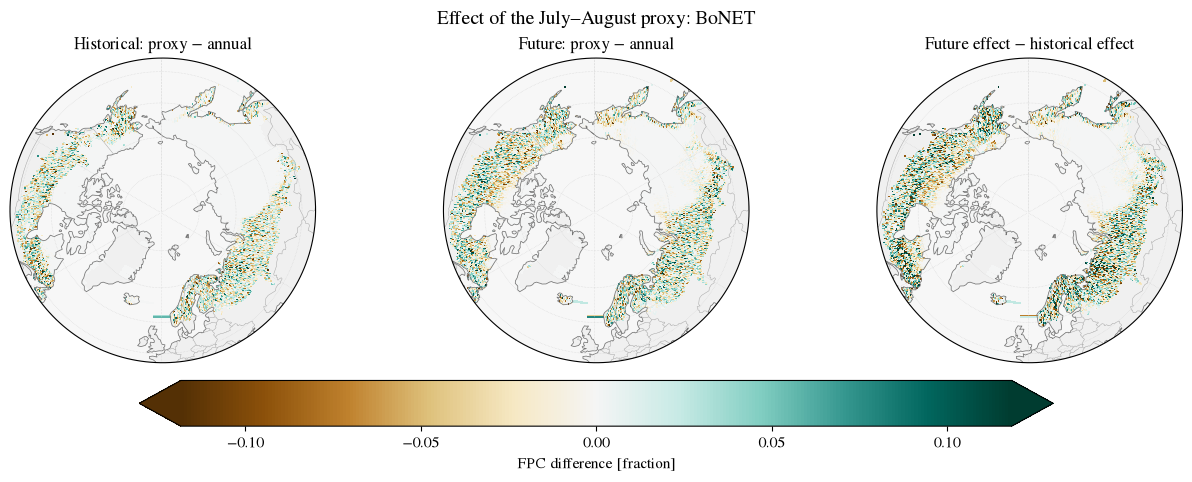

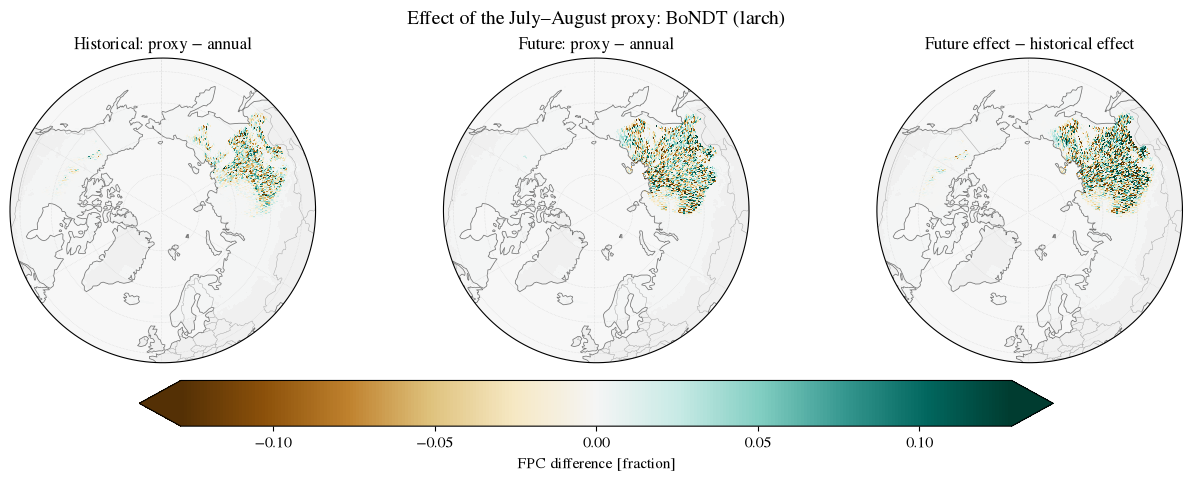

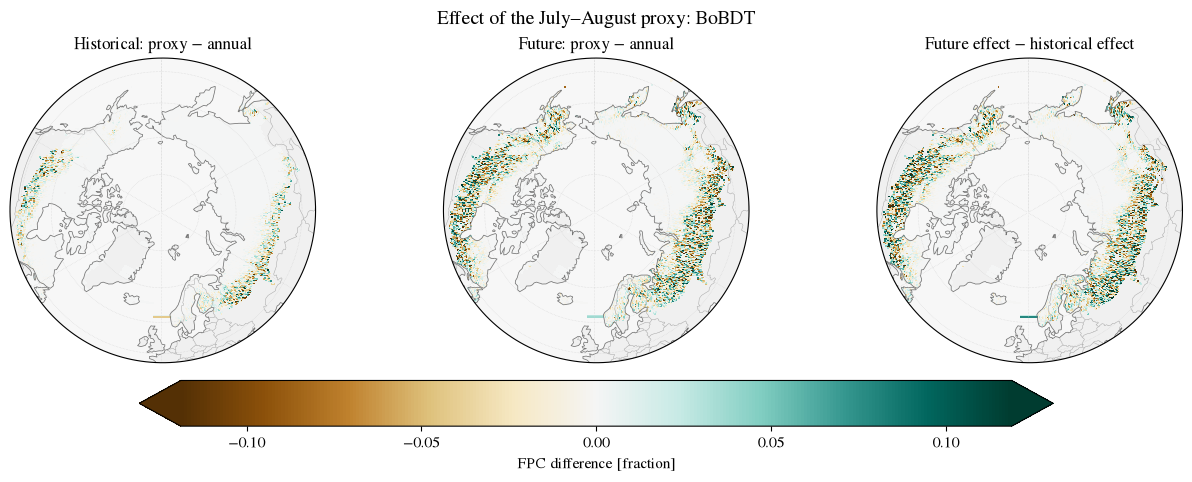

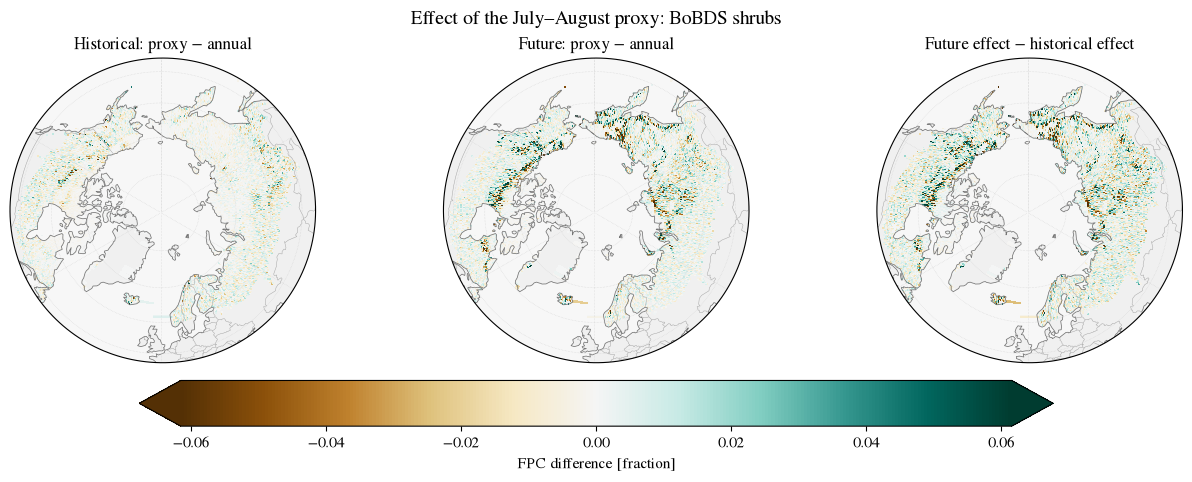

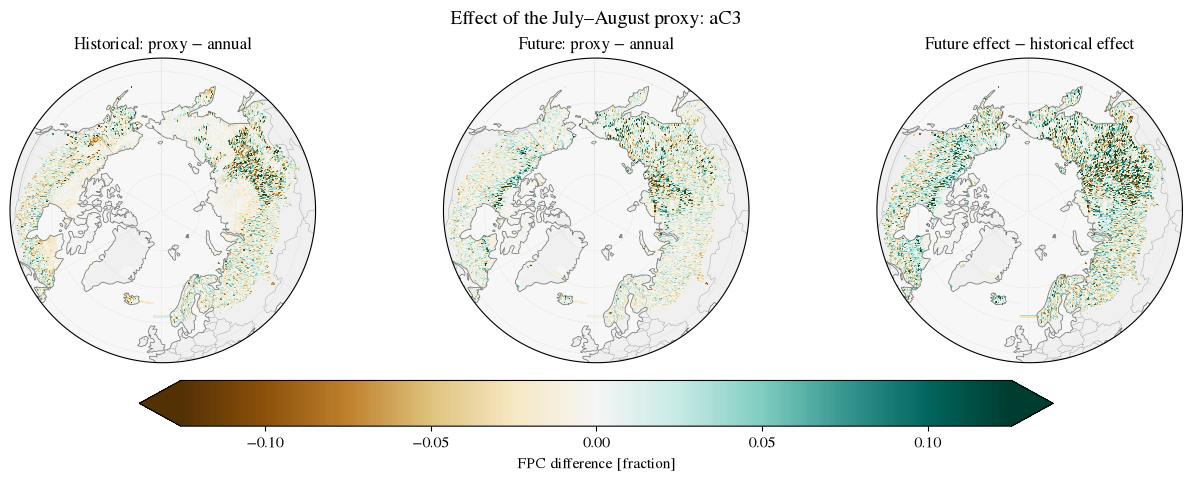

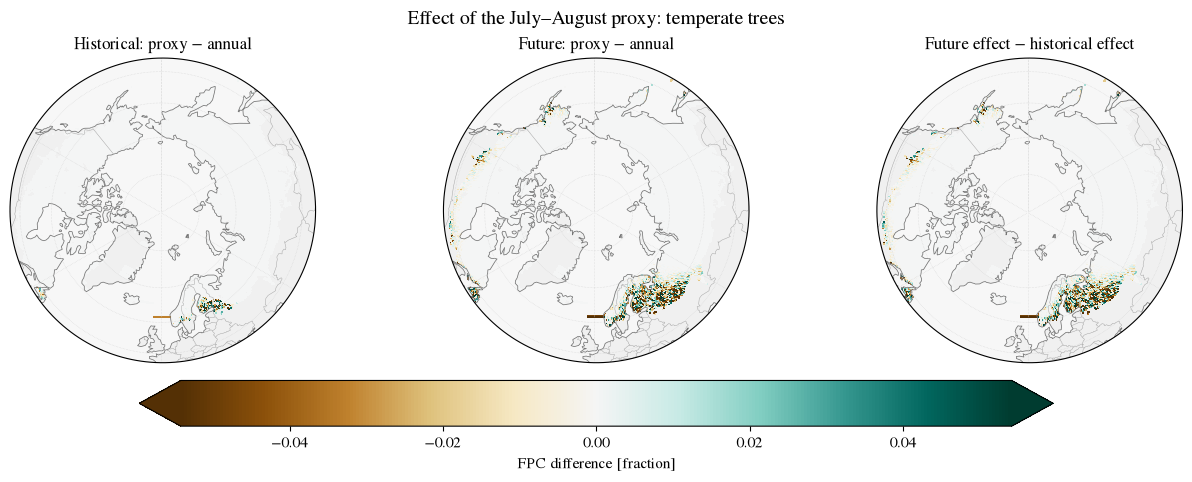

In [7]:
def plot_max_minus_annual(group):
    proxy_effect_change = (
        future_max_minus_annual[group]
        - historical_max_minus_annual[group]
    )

    fields = [
        historical_max_minus_annual[group],
        future_max_minus_annual[group],
        proxy_effect_change,
    ]
    titles = [
        r"Historical: proxy $-$ annual",
        r"Future: proxy $-$ annual",
        r"Future effect $-$ historical effect",
    ]

    projection = ccrs.Orthographic(central_longitude=0, central_latitude=90)
    fig, axes = plt.subplots(
        1, 3, figsize=(13, 4.7),
        subplot_kw={"projection": projection},
        layout="constrained",
    )
    norm = symmetric_norm(fields)

    for ax, field, title in zip(axes, fields, titles):
        image = draw_field(ax, field, title, norm)

    colorbar = fig.colorbar(
        image, ax=axes, orientation="horizontal",
        shrink=0.72, pad=0.05, extend="both",
    )
    colorbar.set_label("FPC difference [fraction]")

    fig.suptitle(
        f"Effect of the July–August proxy: {group}",
        fontsize=14,
    )
    save_figure(fig, f"max_minus_annual_{safe_name(group)}")
    plt.show()


for group in GROUPS:
    plot_max_minus_annual(group)

## 8. Saved figures

The next cell lists the generated PNG files. A matching PDF is saved for every figure.


In [8]:
saved_figures = sorted(FIGURE_DIR.glob("*.png"))
print(f"Saved {len(saved_figures)} PNG figures and matching PDFs to {FIGURE_DIR}")
#for path in saved_figures:
#    print(" ", path.name)


Saved 12 PNG figures and matching PDFs to 06-original_vs_monthly_comparison_figures/fpc-max-difference-figures


## Interpretation guide

- A positive value in **annual: future − historical** means that the CLM group gains FPC in the future annual climatology.
- A positive value in **proxy anomaly − annual anomaly** means the future expansion inferred from the July–August proxy is larger than the expansion inferred from annual means.
- A positive value in **proxy − annual** means annual averaging suppresses the group's summer FPC at that grid cell.
- The difference-of-differences is an absolute FPC difference in fraction units. It is not a percentage or relative change.
